### Read-in downloaded data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
!ls csv

0e9cd673-8e06-4810-b370-8b9930ee312a.csv
2021-10-28-cleaned.csv
2021-10-28.csv
2022-01-03.csv
2022-01-07.csv
2022-01-10.csv
50c39121-3de2-4b6b-b134-bb51732c1d6f.csv
viewer_lat_long_centroids.csv


search data

In [4]:
data = pd.read_csv("csv/2022-01-10.csv", index_col = False)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45689577 entries, 0 to 45689576
Data columns (total 13 columns):
broadcaster_id           object
network                  object
device                   object
age_bucket               int64
gender                   object
lang                     object
country                  object
page                     object
user_searches            int64
user_searches_views      int64
weights                  int64
avg_view_duration        float64
avg_bve_view_duration    float64
dtypes: float64(2), int64(4), object(7)
memory usage: 4.4+ GB


In [6]:
data.describe()

,age_bucket,user_searches,user_searches_views,weights,avg_view_duration,avg_bve_view_duration
count,4.568958e+07,4.568958e+07,4.568958e+07,4.568958e+07,4.568958e+07,4.568958e+07
mean,3.655523e+00,2.406941e+03,3.874395e+01,2.908630e+00,7.183985e+00,1.278096e+01
std,2.088024e+00,1.420121e+04,9.297212e+01,4.519781e+01,1.972702e+02,3.096762e+02
min,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.180000e+02,5.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
50%,3.000000e+00,8.010000e+02,1.600000e+01,1.000000e+00,0.000000e+00,0.000000e+00
75%,5.000000e+00,1.737000e+03,4.000000e+01,1.000000e+00,0.000000e+00,0.000000e+00
max,1.000000e+01,3.021330e+05,2.773000e+03,1.910600e+04,1.212220e+05,1.225740e+05


In [7]:
data.head()

,broadcaster_id,network,device,age_bucket,gender,lang,country,page,user_searches,user_searches_views,weights,avg_view_duration,avg_bve_view_duration
0,NaN,pof,iphone,7,female,en,US,Page 1,17,0,1795,0.0,0.0
1,NaN,pof,android,5,male,en,US,Page 1,313,6,57,0.0,0.0
2,NaN,pof,android,5,male,en,US,Page 1,332,6,54,0.0,0.0
3,NaN,pof,android,5,male,en,US,Page 1,351,6,54,0.0,0.0
4,NaN,pof,android,5,male,en,US,Page 1,608,9,24,0.0,0.0


In [9]:
data['broadcaster_id'].nunique()

35128

### Preprocessing data

In [10]:
df = data.copy()

In [12]:
df.columns

Index(['broadcaster_id', 'network', 'device', 'age_bucket', 'gender', 'lang',
       'country', 'page', 'user_searches', 'user_searches_views', 'weights',
       'avg_view_duration', 'avg_bve_view_duration'],
      dtype='object')

In [13]:
FEATURES = [
	'broadcaster_id',
	'device', 
	'network',
	'age_bucket',
	'gender',
	'lang',
	'country',
	'page',
	'user_searches',
	'user_searches_views'
]

In [14]:
df['log_duration'] = df['avg_view_duration'].apply(lambda x: np.log(1+x))

In [15]:
df.describe(percentiles=np.linspace(0, 1, 11))

,age_bucket,user_searches,user_searches_views,weights,avg_view_duration,avg_bve_view_duration,log_duration
count,4.568958e+07,4.568958e+07,4.568958e+07,4.568958e+07,4.568958e+07,4.568958e+07,4.568958e+07
mean,3.655523e+00,2.406941e+03,3.874395e+01,2.908630e+00,7.183985e+00,1.278096e+01,1.448206e-01
std,2.088024e+00,1.420121e+04,9.297212e+01,4.519781e+01,1.972702e+02,3.096762e+02,7.382521e-01
min,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
0%,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
10%,1.000000e+00,1.170000e+02,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
20%,2.000000e+00,2.460000e+02,4.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
30%,2.000000e+00,3.970000e+02,7.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
40%,3.000000e+00,5.790000e+02,1.100000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,3.000000e+00,8.010000e+02,1.600000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


<AxesSubplot:ylabel='Frequency'>

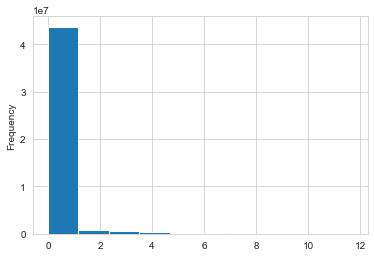

In [16]:
df['log_duration'].plot(kind='hist', bins=10)

### Lightgbm Model

In [17]:
from typing import Dict, Iterable, Tuple
import lightgbm as lgb
import pandas as pd
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import train_test_split

In [18]:
def split(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """return distinct train and test sets"""
    return train_test_split(df, random_state=0, test_size=0.3)

In [19]:
def decompose(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series, pd.Series]:
    """break down data into features, labels and weights"""
    return df.drop(['y', 'w'], axis=1), df.y, df.w

In [20]:
def ungroup(X: pd.DataFrame, w: pd.DataFrame) -> pd.DataFrame:
    """expand all repeated columns"""
    return X.reindex(X.index.repeat(w))

In [21]:
def group(X: pd.DataFrame) -> pd.DataFrame:
    """append weight to pandas dataframe by groupby all columns"""
    return X.groupby(list(X.columns)).size().to_frame('w').reset_index()

In [22]:
def get_feature_mappings(X: pd.DataFrame) -> Dict[str, Dict[str, int]]:
    """map of value to pandas category"""
    return {
        f: {str(x): i
            for i, x in enumerate(X[f].cat.categories, start=1)}
        for f in X
    }

In [23]:
def etl(X: pd.DataFrame,
        y: pd.Series,
        w: pd.Series = None) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """transform the data"""
    X = X.assign(y=y)
    if w is not None:
        X_train, X_test = split(ungroup(X, w))
        return group(X_train), group(X_test)
    else:
        X['w'] = 1
        return split(X)

In [24]:
def predict(model: lgb.Booster,
            X: pd.DataFrame,
            regression: bool = False) -> pd.Series:
    """prediction wrapper"""
    return model.predict(X) if regression else model.predict_proba(X)[:, 1]

In [25]:
def evaluate(X: pd.DataFrame,
             y: pd.Series,
             w: pd.Series,
             y_pred: pd.Series,
             regression: bool = False) -> Dict[str, any]:
    """calculate evaluation metrics"""
    metrics = {'records': str(len(y)), 'weights': str(sum(w))}
    metrics['raw_accuracy'] = prediction_metrics(y, y_pred, weights=w)
    if not regression:
        metrics['log_loss'] = log_loss(y, y_pred, sample_weight=w)
        metrics['roc_auc_score'] = roc_auc_score(y, y_pred, sample_weight=w)
    return metrics

In [26]:
from sklearn import metrics
def prediction_metrics(var_y, var_y_pred, weights=None):
    if weights is None:
        weights = np.ones(len(var_y))
    avg = np.average(var_y, weights=weights)
    pred_avg = np.average(var_y_pred, weights=weights)
    bias2 = np.average(var_y - var_y_pred, weights=weights) ** 2
    var = np.average(var_y_pred ** 2, weights=weights) - np.average(var_y_pred, weights=weights) ** 2
    square_error = metrics.mean_squared_error(var_y, var_y_pred, weights)
    abs_err = metrics.mean_absolute_error(var_y, var_y_pred, weights)
    r2_score = metrics.r2_score(var_y, var_y_pred, weights)
    return dict(avg=avg, pred_avg=pred_avg, bias2=bias2, var=var, square_error=square_error, abs_err=abs_err, abs_err_ratio=abs_err / avg, r2_score=r2_score)

In [27]:
def build_model(
    X: pd.DataFrame,
    y: pd.Series,
    w: pd.Series = None,
    categories: Iterable[str] = [],
    unencoded_categories: Iterable[str] = [],
    params: Dict[str, any] = {},
    regression: bool = False
) -> Tuple[lgb.LGBMModel, Dict[str, any], pd.DataFrame, pd.DataFrame]:
    """take the sql data and output model and metadata"""
    X[unencoded_categories] = X[unencoded_categories].astype('category')
    metadata = {
        'model_type': 'lightgbm',
        'features': list(X),
        'category_features': categories,
        'mappings': get_feature_mappings(X[unencoded_categories]),
    }

    train_df, test_df = etl(X, y, w)
    X, y, w = decompose(train_df)
    
    model = (lgb.LGBMRegressor if regression else lgb.LGBMClassifier)(random_state=0, **params)
    model.fit(X, y, w, categorical_feature=categories)
    train_df['y_pred'] = predict(model, X, regression)
    
    metadata['train_accuracy'] = evaluate(X, y, w, train_df['y_pred'], regression)
    metadata['train_accuracy']['data_type'] = 'train'
    
    X, y, w = decompose(test_df)
    test_df['y_pred'] = predict(model, X, regression)
    metadata['test_accuracy'] = evaluate(X, y, w, test_df['y_pred'], regression)
    metadata['test_accuracy']['data_type'] = 'test'
    return model, metadata, train_df, test_df

In [38]:
pred_model, pred_metadata, train_df, test_df = build_model(
    X=df[FEATURES],
    y=df['log_duration'],
    w=df['weights'],
    categories=FEATURES,
    unencoded_categories=FEATURES,
    params={'n_estimators': 300, 'num_leaves': 100, "learning_rate": 0.1, 'max_bin': 100},
    regression=True
)

/Users/lhuang/opt/miniconda3/envs/tensorflow2.5/lib/python3.7/site-packages/pandas/core/frame.py:3509: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[k1] = value[k2]
/Users/lhuang/opt/miniconda3/envs/tensorflow2.5/lib/python3.7/site-packages/lightgbm/basic.py:1551: UserWarning: Using categorical_feature in Dataset.
  warnings.warn('Using categorical_feature in Dataset.')
/Users/lhuang/opt/miniconda3/envs/tensorflow2.5/lib/python3.7/site-packages/sklearn/utils/validation.py:72: FutureWarning: Pass sample_weight=0          1
1          1
2          1
3          1
4          1
          ..
1585896    1
1585897    1
1585898    1
1585899    1
1585900    1
Name: w, Length: 1585901, dtype: int64 as keyword args. From version 1.0 (renaming of 0.25) pa

In [39]:
pred_metadata['train_accuracy']

{'records': '1585901',
 'weights': '1589899',
 'raw_accuracy': {'avg': 2.924044128270504,
  'pred_avg': 2.924029577678352,
  'bias2': 2.1171973199158627e-10,
  'var': 0.7106558834450798,
  'square_error': 1.8554498516867406,
  'abs_err': 1.0581508329569485,
  'abs_err_ratio': 0.3618792284037167,
  'r2_score': 0.3546770775188466},
 'data_type': 'train'}

In [40]:
pred_metadata['test_accuracy']

{'records': '679409',
 'weights': '680258',
 'raw_accuracy': {'avg': 2.926404005560747,
  'pred_avg': 2.9232520304245475,
  'bias2': 9.934947259211947e-06,
  'var': 0.6784311715454621,
  'square_error': 2.276789982090957,
  'abs_err': 1.1720586285310883,
  'abs_err_ratio': 0.40051155831660457,
  'r2_score': 0.2082075825590326},
 'data_type': 'test'}

In [41]:
train_df.head()

,broadcaster_id,device,network,age_bucket,gender,lang,country,page,user_searches,user_searches_views,y,w,y_pred
0,00CsiVyzDz,android,meetme,2,male,en,SA,Page 1,90,2,3.218876,1,2.781798
1,00CsiVyzDz,android,meetme,2,male,en,SA,Page 1,713,32,2.197225,1,2.431338
2,00CsiVyzDz,android,meetme,2,male,en,SA,Page 1,716,33,0.693147,1,2.481392
3,00CsiVyzDz,android,meetme,2,male,en,SA,Page 1,1028,206,1.386294,1,1.545202
4,00CsiVyzDz,android,meetme,2,male,en,SA,Page 1,1029,207,1.098612,1,1.702930


In [42]:
train_df['y_pred_binned'] = pd.qcut(train_df['y_pred'], q=10)

In [43]:
train_df['y_pred_binned'].value_counts()

(0.0812, 1.904]    158591
(4.016, 8.433]     158590
(3.578, 4.016]     158590
(3.296, 3.578]     158590
(3.059, 3.296]     158590
(2.85, 3.059]      158590
(2.648, 2.85]      158590
(2.433, 2.648]     158590
(2.197, 2.433]     158590
(1.904, 2.197]     158590
Name: y_pred_binned, dtype: int64

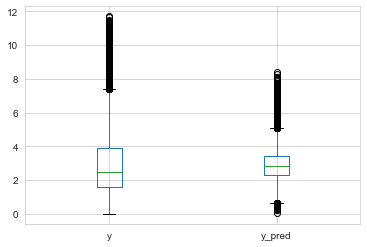

In [44]:
plt.figure()
boxplot = train_df.boxplot(column=['y', 'y_pred'])

In [45]:
def cnt_distinct(x):
    return len(set(x))

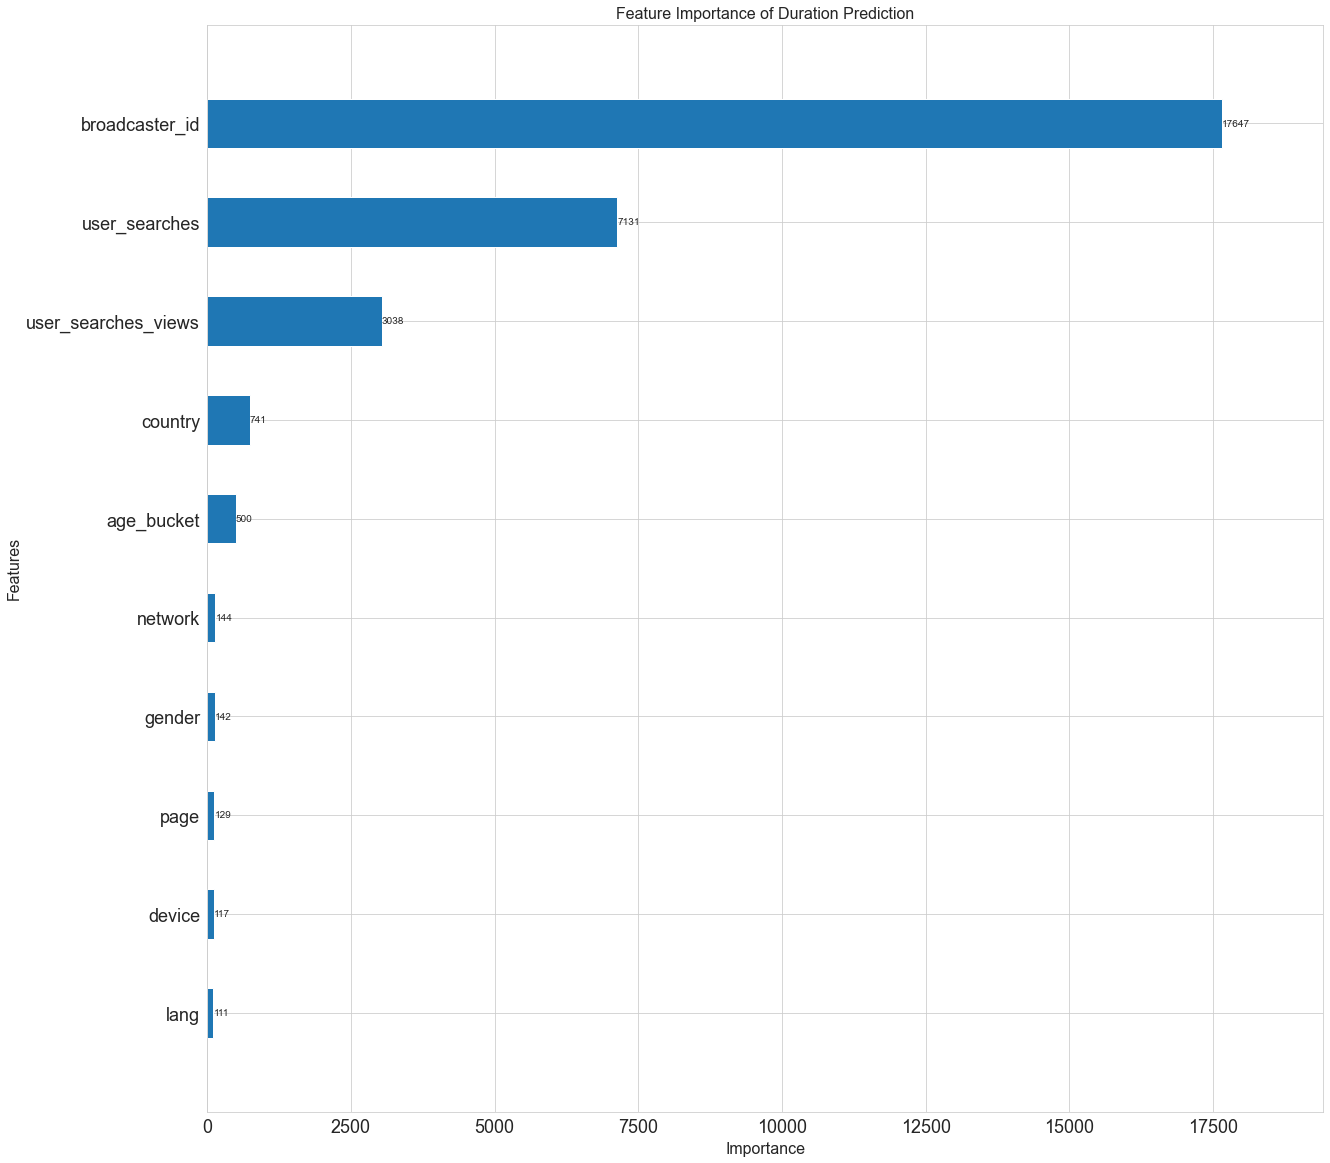

In [46]:
lgb.plot_importance(pred_model, figsize=(20,20), height=0.5)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title("Feature Importance of Duration Prediction", fontsize=16)
plt.xlabel("Importance", fontsize=16)
plt.ylabel("Features", fontsize=16)
plt.show()